In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv("C:/Data Analyst Projects/03_Banking & Risk Analytics/loans_full_schema.csv")

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (10000, 56)


,Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,1,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,2,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,3,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,4,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,5,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [3]:
cols_to_keep = [
    "emp_title",
    "emp_length",
    "state",
    "homeownership",
    "annual_income",
    "verified_income",
    "debt_to_income",
    "delinq_2y",
    "months_since_last_delinq",
    "earliest_credit_line",
    "inquiries_last_12m",
    "total_credit_lines",
    "open_credit_lines",
    "total_credit_limit",
    "total_credit_utilized",
    "num_historical_failed_to_pay",
    "public_record_bankrupt",
    "loan_purpose",
    "application_type",
    "loan_amount",
    "term",
    "interest_rate",
    "installment",
    "grade",
    "sub_grade",
    "issue_month",
    "loan_status",
    "balance",
    "paid_total",
    "paid_principal",
    "paid_interest",
    "paid_late_fees",
]

df_clean = df[cols_to_keep].copy()
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   emp_title                     9167 non-null   str    
 1   emp_length                    9183 non-null   float64
 2   state                         10000 non-null  str    
 3   homeownership                 10000 non-null  str    
 4   annual_income                 10000 non-null  float64
 5   verified_income               10000 non-null  str    
 6   debt_to_income                9976 non-null   float64
 7   delinq_2y                     10000 non-null  int64  
 8   months_since_last_delinq      4342 non-null   float64
 9   earliest_credit_line          10000 non-null  int64  
 10  inquiries_last_12m            10000 non-null  int64  
 11  total_credit_lines            10000 non-null  int64  
 12  open_credit_lines             10000 non-null  int64  
 13  total_credit_

In [9]:
df_clean["emp_length"] = df_clean["emp_length"].fillna(0)

df_clean["emp_title"] = df_clean["emp_title"].fillna("Unknown")

df_clean["debt_to_income"] = df_clean["debt_to_income"].fillna(
    df_clean["debt_to_income"].median()
)

df_clean["months_since_last_delinq"] = df_clean[
    "months_since_last_delinq"
].fillna(-1)

df_clean.isnull().sum()

emp_title                       0
emp_length                      0
state                           0
homeownership                   0
annual_income                   0
verified_income                 0
debt_to_income                  0
delinq_2y                       0
months_since_last_delinq        0
earliest_credit_line            0
inquiries_last_12m              0
total_credit_lines              0
open_credit_lines               0
total_credit_limit              0
total_credit_utilized           0
num_historical_failed_to_pay    0
public_record_bankrupt          0
loan_purpose                    0
application_type                0
loan_amount                     0
term                            0
interest_rate                   0
installment                     0
grade                           0
sub_grade                       0
issue_month                     0
loan_status                     0
balance                         0
paid_total                      0
paid_principal

In [14]:
default_statuses = ["Charged Off", "Late (31-120 days)", "Default"]

df_clean["is_default"] = np.where(
    df_clean["loan_status"].isin(default_statuses), 1, 0
)

print("Loan Status Count:")
print(df_clean["is_default"].value_counts(normalize=True) * 100)

In [15]:
df_clean[
    [
        "annual_income",
        "loan_amount",
        "interest_rate",
        "debt_to_income",
        "is_default",
    ]
].describe()

,annual_income,loan_amount,interest_rate,debt_to_income,is_default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.922215e+04,16361.922500,12.427524,19.304020,0.007300
std,6.473429e+04,10301.956759,5.001105,14.987074,0.085132
min,0.000000e+00,1000.000000,5.310000,0.000000,0.000000
25%,4.500000e+04,8000.000000,9.430000,11.067500,0.000000
50%,6.500000e+04,14500.000000,11.980000,17.570000,0.000000
75%,9.500000e+04,24000.000000,15.050000,24.990000,0.000000
max,2.300000e+06,40000.000000,30.940000,469.090000,1.000000


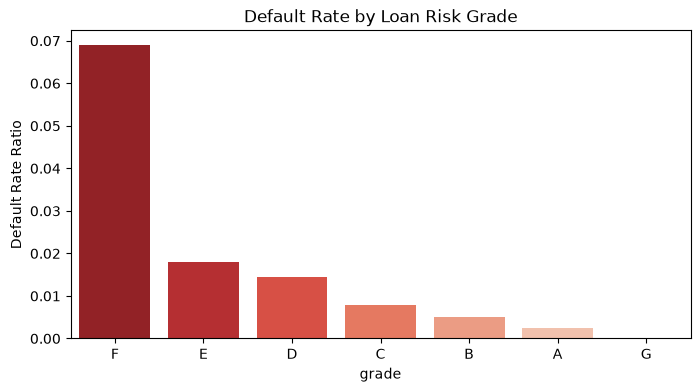

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

grade_risk = (
    df_clean.groupby("grade")["is_default"]
    .mean()
    .reset_index()
    .sort_values(by="is_default", ascending=False)
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=grade_risk,
    x="grade",
    y="is_default",
    hue="grade",
    palette="Reds_r",
    legend=False,
)
plt.title("Default Rate by Loan Risk Grade")
plt.ylabel("Default Rate Ratio")
plt.show()

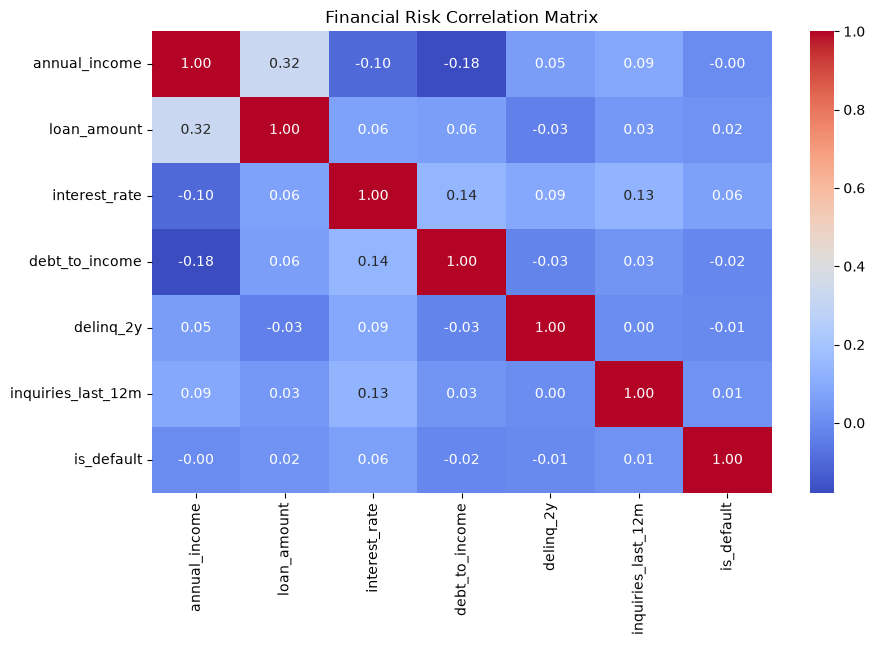

In [18]:
plt.figure(figsize=(10, 6))
numeric_cols = [
    "annual_income",
    "loan_amount",
    "interest_rate",
    "debt_to_income",
    "delinq_2y",
    "inquiries_last_12m",
    "is_default",
]
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Financial Risk Correlation Matrix")
plt.show()

In [19]:
df_clean.to_csv("cleaned_loan_data.csv", index=False)
print("Final Cleaned Data Exported Successfully!")

Final Cleaned Data Exported Successfully!
